In [62]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [63]:
df=pd.read_csv("Week2MiniProjectDS.csv")


In [64]:
df.shape

(891, 12)

In [65]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [67]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [68]:
df.describe(include='object')# include object columns 

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [69]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [70]:
import warnings
warnings.filterwarnings('ignore')

# replacing the null values in age column with the median 
df['Age'].fillna(df['Age'].median(), inplace=True)

# droping  the cabin column as it has more null values 
if 'Cabin' in df.columns:
    df.drop(columns=["Cabin"], inplace=True)
    
# filling the embarked column with the mode as it is the categorical data 
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)



In [71]:
df.isnull().sum()# all the null values are taken care of 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [72]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 120],labels=['Child', 'Teen', 'Adult', 'Elderly'])
# creating categorical data 

In [78]:
df['FamilyAboard'] = df['SibSp'] + df['Parch']

In [79]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup,FamilyAboard
0,1,No,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Adult,1
1,2,Yes,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult,1
2,3,Yes,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Adult,0
3,4,Yes,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Adult,1
4,5,No,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Adult,0


gender vs survival

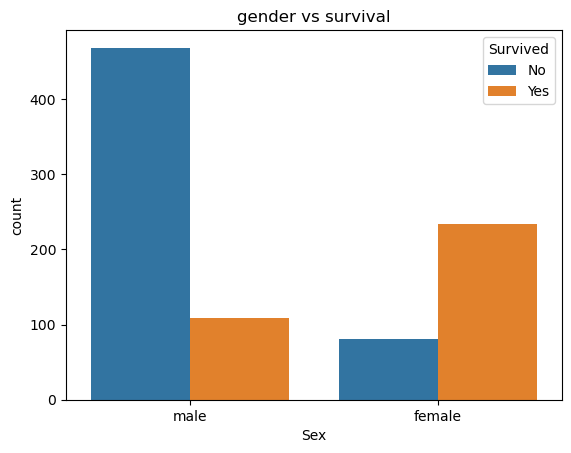

In [74]:
df['Survived'] = df['Survived'].map({0: 'No', 1: 'Yes'})
sns.countplot(x='Sex',hue='Survived',data=df,)
plt.title("gender vs survival")
plt.show()

females had better survival rate than the males 

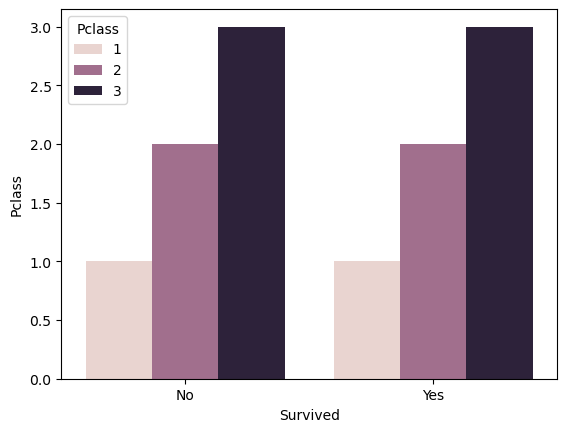

In [75]:
# survival by class 
sns.barplot(x="Survived",y="Pclass",hue="Pclass",data=df)
plt.show()

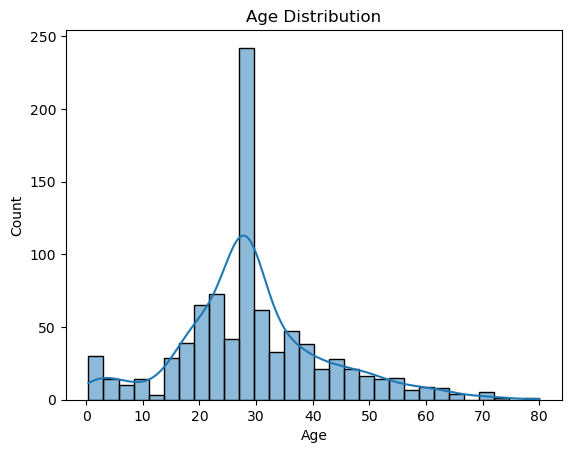

In [76]:
sns.histplot(df['Age'], kde=True, bins=30)
plt.title("Age Distribution")
plt.show()


most of the age group is btw 25 to 30 

<Axes: xlabel='Age', ylabel='Count'>

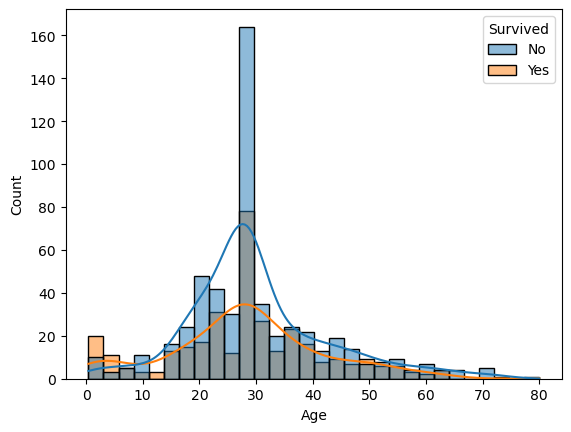

In [77]:
# survival by age 
sns.histplot(data=df,x='Age',hue='Survived',kde=True)

children had better survival rate 

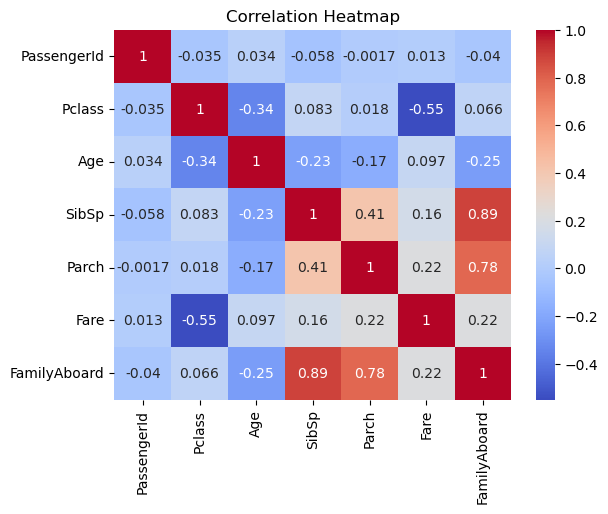

In [80]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

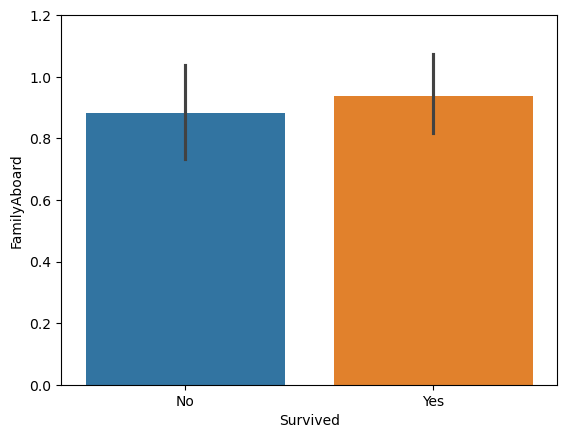

In [86]:
sns.barplot(x='Survived',y='FamilyAboard',hue='Survived',data=df)
plt.yticks([0,0.2,0.4,0.6,0.8,1.0,1.2])
plt.show()

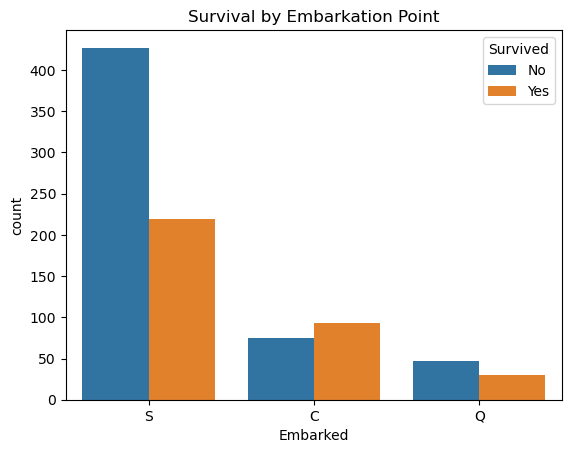

In [87]:
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title("Survival by Embarkation Point")
plt.show()

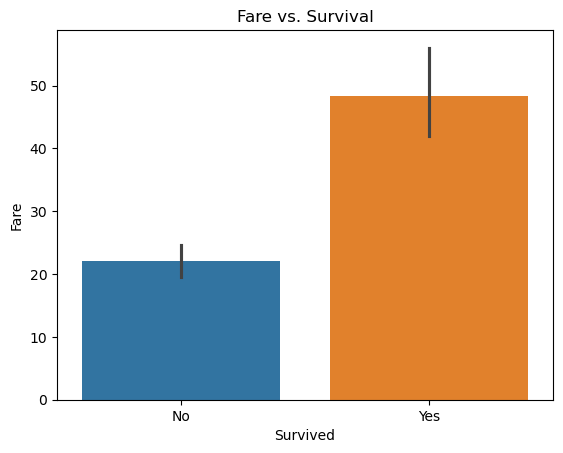

In [90]:
sns.barplot(x='Survived', y='Fare', data=df,hue='Survived')
plt.title("Fare vs. Survival")
plt.show()


higher fare people has better chances of survival 